# Chapter 1 — Introduction
**Elementary Fluid Dynamics · Acheson (1990)**

Colab visualization notebook · SeoulTech PSE Lab

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com)

---
**Contents**
1. Reynolds Number & Flow Regimes (§1.1–1.2)
2. Re Number Map — Familiar Flows
3. Elementary Irrotational Flows — Streamlines (§1.4)
4. Potential Flow Past a Cylinder — Effect of Circulation (§1.4, 1.6)
5. Rankine Vortex — Velocity, Vorticity & Circulation (§1.4)
6. Rankine Vortex — 2D Cross-section
7. Bernoulli Pressure Distribution on a Cylinder (§1.3)
8. Course Roadmap — Chapter Logical Flow (§1.7)


## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Circle, FancyArrowPatch, FancyBboxPatch
import matplotlib.patches as mpatches
from scipy.integrate import solve_ivp
import warnings
warnings.filterwarnings('ignore')

# Dark theme matching slides
plt.rcParams.update({
    'figure.facecolor':  '#1e1e2e',
    'axes.facecolor':    '#27273d',
    'axes.edgecolor':    '#313244',
    'axes.labelcolor':   '#cdd6f4',
    'xtick.color':       '#6c7086',
    'ytick.color':       '#6c7086',
    'text.color':        '#cdd6f4',
    'grid.color':        '#313244',
    'grid.linewidth':    0.5,
    'lines.linewidth':   1.5,
    'font.size':         12,
    'axes.titlesize':    14,
    'axes.titleweight':  'bold',
    'figure.dpi':        120,
})

TEAL   = '#4ec9b0'
ORANGE = '#ce9178'
BLUE   = '#9cdcfe'
PURPLE = '#c792ea'
MUTED  = '#6c7086'
FG     = '#cdd6f4'
BG     = '#1e1e2e'

print("Setup complete.")

Setup complete.


## 1 · Reynolds Number & Flow Regimes

The Reynolds number $\mathrm{Re} = UL/\nu$ controls the transition from
laminar to turbulent flow.  The interactive slider below lets you explore
how velocity and length scale affect the regime.

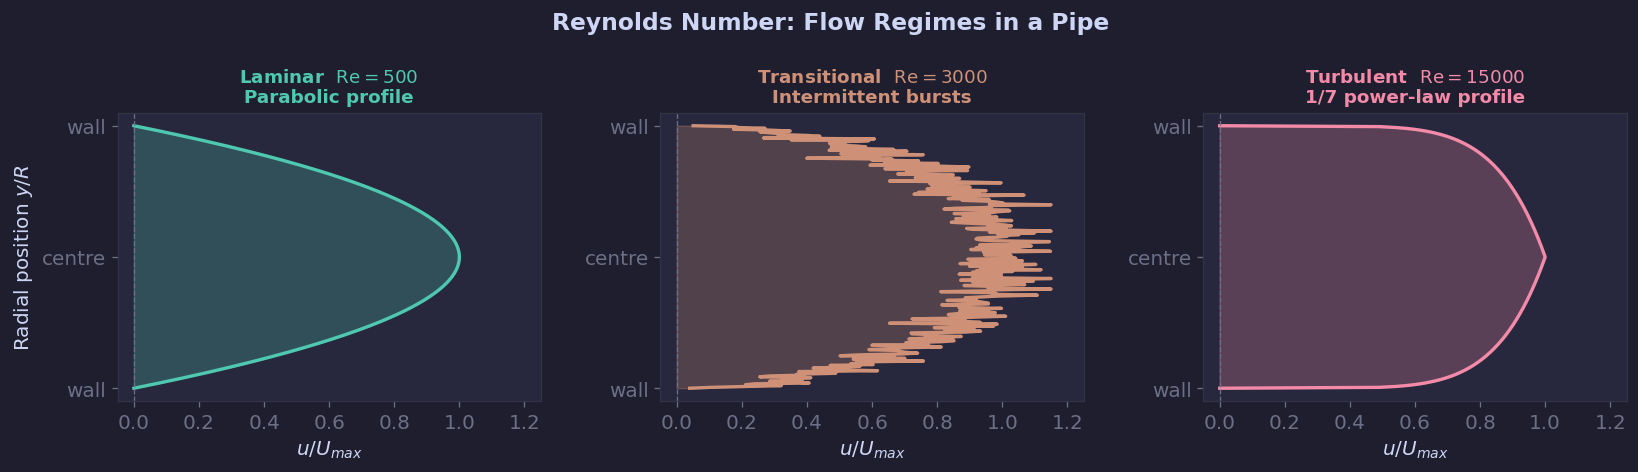

Figure 1.1: Velocity profiles at different Re


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Reynolds Number: Flow Regimes in a Pipe", color=FG, fontsize=14, fontweight='bold')

Re_values = [500, 3000, 15000]
labels    = [r'Laminar  $\mathrm{Re}=500$',
             r'Transitional  $\mathrm{Re}=3000$',
             r'Turbulent  $\mathrm{Re}=15000$']
colors    = [TEAL, ORANGE, '#f38ba8']

for ax, Re, label, col in zip(axes, Re_values, labels, colors):
    y = np.linspace(-1, 1, 300)
    if Re < 2300:                       # parabolic (Hagen-Poiseuille)
        u = 1 - y**2
        title_note = "Parabolic profile"
    elif Re < 4000:                     # transitional — blunt + ripple
        u = (1 - y**2)**0.5 + 0.08 * np.random.RandomState(42).randn(300)
        u = np.clip(u, 0, 1.15)
        title_note = "Intermittent bursts"
    else:                               # turbulent — 1/7 power law
        u = (1 - np.abs(y))**(1/7)
        title_note = "1/7 power-law profile"

    ax.fill_betweenx(y, 0, u, color=col, alpha=0.25)
    ax.plot(u, y, color=col, lw=2)
    ax.axvline(0, color=MUTED, lw=0.8, ls='--')
    ax.set_xlim(-0.05, 1.25)
    ax.set_xlabel("$u / U_{max}$", color=FG)
    ax.set_title(f"{label}\n{title_note}", color=col, fontsize=11)
    ax.set_yticks([-1, 0, 1])
    ax.set_yticklabels(['wall', 'centre', 'wall'])

axes[0].set_ylabel("Radial position $y/R$", color=FG)
plt.tight_layout()
plt.savefig('ch01_fig1_reynolds_profiles.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("Figure 1.1: Velocity profiles at different Re")

### Re number map: familiar flows

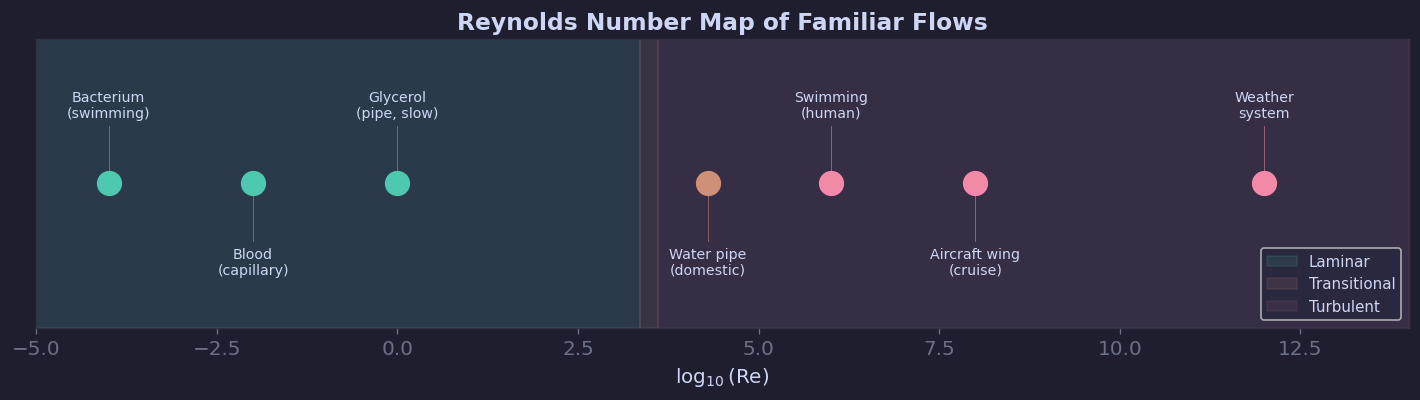

In [3]:
flows = {
    'Bacterium\n(swimming)':    1e-4,
    'Blood\n(capillary)':       1e-2,
    'Glycerol\n(pipe, slow)':   1,
    'Water pipe\n(domestic)':   2e4,
    'Swimming\n(human)':        1e6,
    'Aircraft wing\n(cruise)':  1e8,
    'Weather\nsystem':          1e12,
}

fig, ax = plt.subplots(figsize=(12, 3.5))
Re_vals = list(flows.values())
names   = list(flows.keys())

y_offsets = [0.72, 0.28, 0.72, 0.28, 0.72, 0.28, 0.72]
for i, (name, Re) in enumerate(flows.items()):
    col = TEAL if Re < 2300 else (ORANGE if Re < 1e5 else '#f38ba8')
    ax.scatter(np.log10(Re), 0.5, s=200, color=col, zorder=5)
    yoff = y_offsets[i]
    va   = 'bottom' if yoff > 0.5 else 'top'
    ax.text(np.log10(Re), yoff, name, ha='center', va=va, fontsize=8.5, color=FG)
    # connector line
    ax.plot([np.log10(Re), np.log10(Re)], [0.5, yoff + (0.02 if va=='top' else -0.02)],
            color=col, lw=0.6, alpha=0.5)

# regime bands
ax.axvspan(-5, np.log10(2300), alpha=0.12, color=TEAL,   label='Laminar')
ax.axvspan(np.log10(2300), np.log10(4000), alpha=0.12, color=ORANGE, label='Transitional')
ax.axvspan(np.log10(4000), 14, alpha=0.08, color='#f38ba8', label='Turbulent')

ax.set_xlim(-5, 14)
ax.set_ylim(0, 1)
ax.set_xlabel(r'$\log_{10}(\mathrm{Re})$', color=FG)
ax.set_title('Reynolds Number Map of Familiar Flows', color=FG)
ax.set_yticks([])
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('ch01_fig2_re_map.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

## 2 · Streamlines of Elementary Irrotational Flows

For 2-D irrotational flow, the stream function $\psi$ satisfies $\nabla^2\psi=0$.
Streamlines are contours of $\psi$.

| Flow | Complex potential $w(z)$ | Stream function $\psi$ |
|------|--------------------------|------------------------|
| Uniform ($x$) | $Uz$ | $Uy$ |
| Line source | $\frac{m}{2\pi}\ln z$ | $\frac{m}{2\pi}\theta$ |
| Free vortex | $-\frac{i\Gamma}{2\pi}\ln z$ | $-\frac{\Gamma}{2\pi}\ln r$ |
| Doublet | $-\frac{\mu}{2\pi z}$ | $\frac{\mu \sin\theta}{2\pi r}$ |

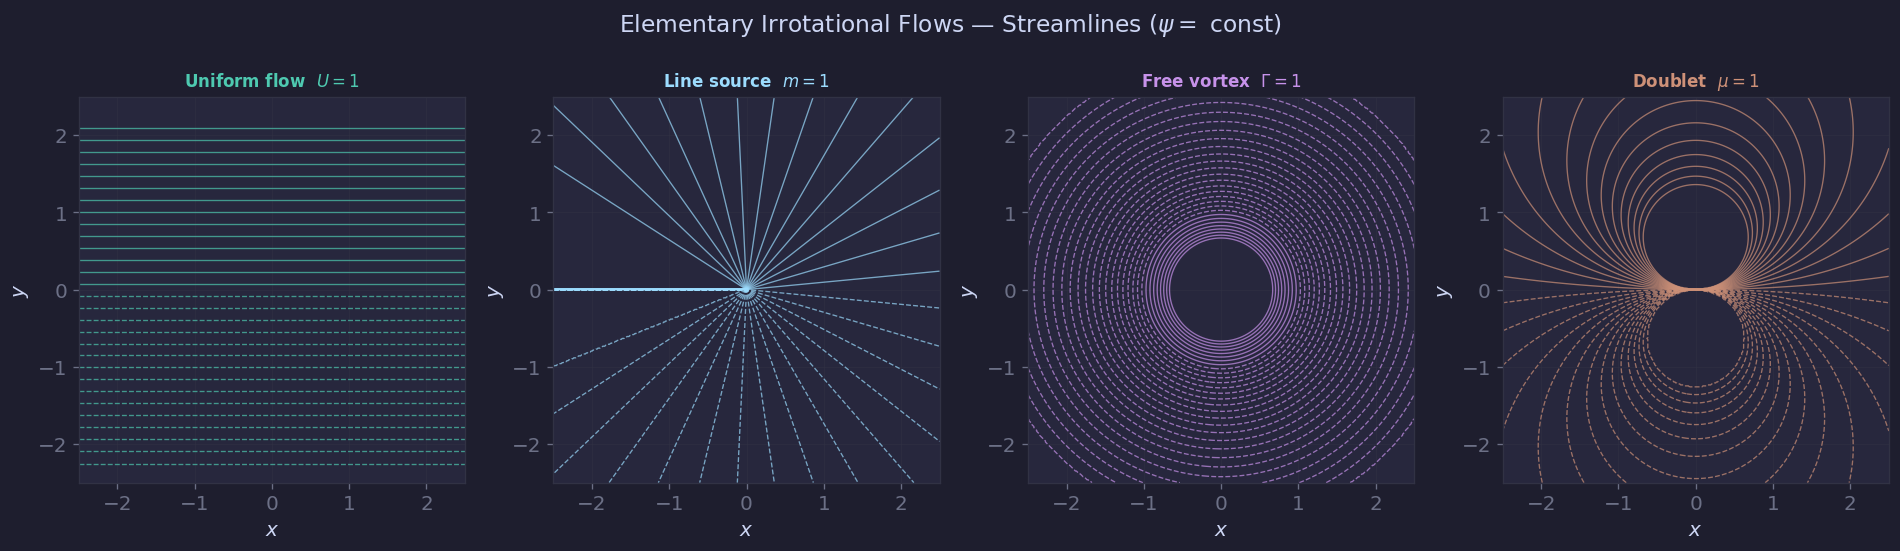

Figure 1.2: Elementary irrotational flow streamlines


In [4]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
fig.suptitle("Elementary Irrotational Flows — Streamlines ($\\psi = $ const)", color=FG, fontsize=14)

L = 2.5
x = np.linspace(-L, L, 400)
y = np.linspace(-L, L, 400)
X, Y = np.meshgrid(x, y)
R    = np.sqrt(X**2 + Y**2)
R    = np.where(R < 0.01, 0.01, R)   # avoid log(0)
Th   = np.arctan2(Y, X)

configs = [
    ("Uniform flow  $U=1$",         Y,                           TEAL),
    ("Line source  $m=1$",           np.arctan2(Y, X)/(2*np.pi), BLUE),
    ("Free vortex  $\\Gamma=1$",    -np.log(R)/(2*np.pi),        PURPLE),
    ("Doublet  $\\mu=1$",            Y/(2*np.pi*R**2),            ORANGE),
]

for ax, (title, psi, col) in zip(axes.flat, configs):
    # clip extreme values for clean contours
    psi_c = np.clip(psi, np.percentile(psi, 5), np.percentile(psi, 95))
    levels = np.linspace(psi_c.min(), psi_c.max(), 30)
    ax.contour(X, Y, psi_c, levels=levels, colors=col, alpha=0.7, linewidths=0.8)
    ax.set_aspect('equal')
    ax.set_title(title, color=col, fontsize=10)
    ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
    ax.set_xlim(-L, L); ax.set_ylim(-L, L)
    ax.grid(True, lw=0.3)

plt.tight_layout()
plt.savefig('ch01_fig3_elementary_flows.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("Figure 1.2: Elementary irrotational flow streamlines")

## 3 · Potential Flow Past a Cylinder

Complex potential:
$$w(z) = U\!\left(z + \frac{a^2}{z}\right) - \frac{i\Gamma}{2\pi}\ln z$$

Streamlines are contours of $\psi = \mathrm{Im}(w)$.
The slider below controls the circulation $\Gamma$.

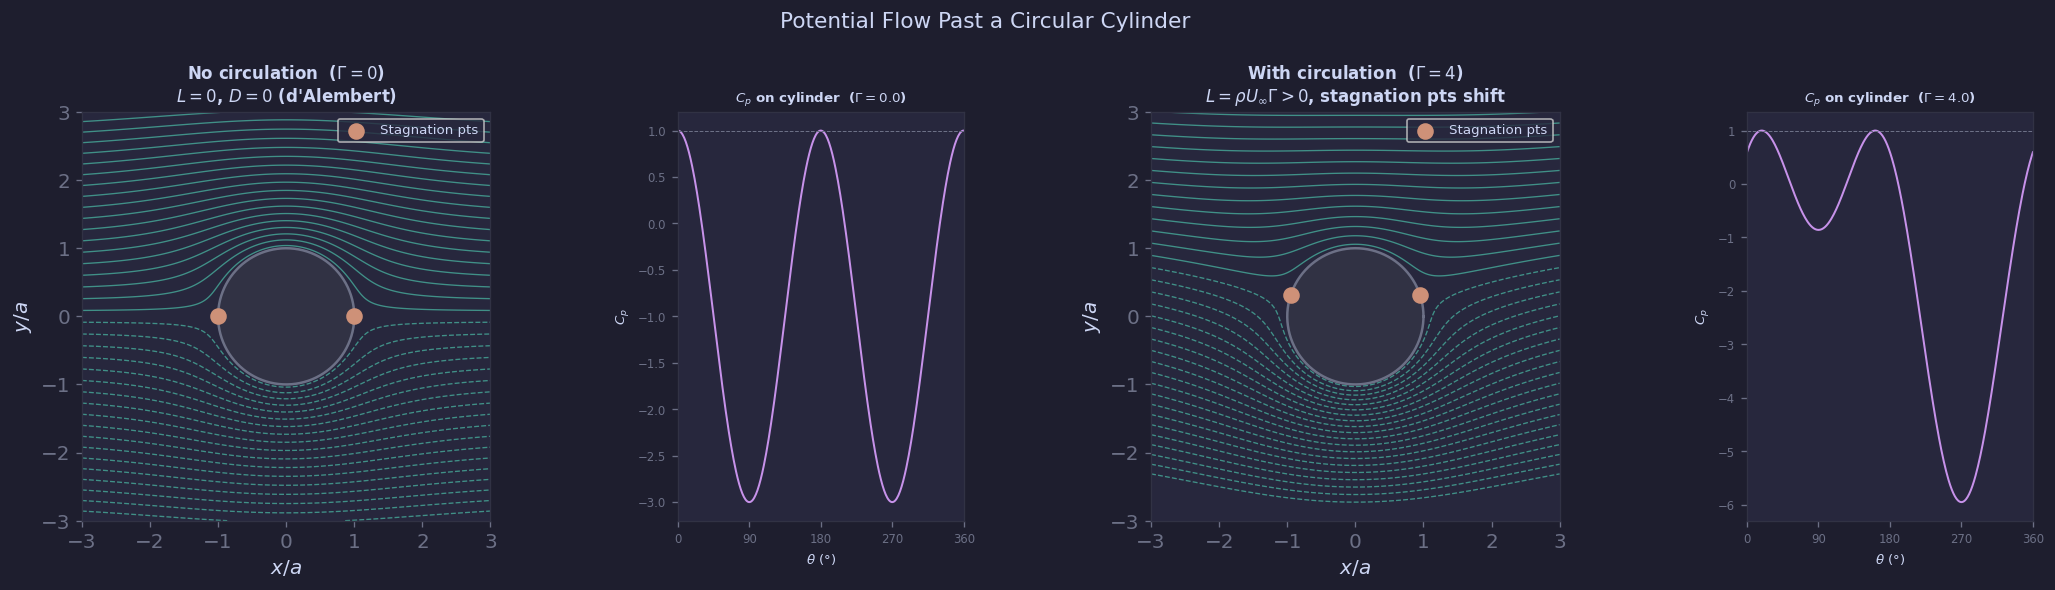

Figure 1.3: Potential flow past a cylinder (left: Γ=0, right: Γ=4)
  Γ=0: symmetric, no lift, D'Alembert drag = 0
  Γ=4: asymmetric, lift L = ρ·U·Γ


In [5]:
def cylinder_streamlines(ax, ax2, Gamma=0.0, U=1.0, a=1.0):
    """Plot streamlines and Cp for flow past a cylinder on given axes."""
    L = 3.0
    x = np.linspace(-L, L, 500)
    y = np.linspace(-L, L, 500)
    X, Y = np.meshgrid(x, y)
    Z    = X + 1j*Y
    R    = np.abs(Z)
    mask = R < a

    with np.errstate(divide='ignore', invalid='ignore'):
        w   = U*(Z + a**2/Z) - 1j*Gamma/(2*np.pi)*np.log(Z)
        psi = np.where(mask, np.nan, np.imag(w))

    Gamma_str = f"$\\Gamma = {Gamma:.1f}$"
    levels = np.linspace(-3, 3, 40)
    ax.contour(X, Y, psi, levels=levels, colors=TEAL, alpha=0.65, linewidths=0.8)

    theta = np.linspace(0, 2*np.pi, 300)
    ax.fill(a*np.cos(theta), a*np.sin(theta), color='#313244', zorder=5)
    ax.plot(a*np.cos(theta), a*np.sin(theta), color=MUTED, lw=1.5, zorder=6)

    disc = -Gamma**2 / (4*np.pi**2) + 4*U**2*a**2
    if disc >= 0:
        sqrt_disc = np.sqrt(disc + 0j)
        z1 = (1j*Gamma/(2*np.pi) + sqrt_disc) / (2*U)
        z2 = (1j*Gamma/(2*np.pi) - sqrt_disc) / (2*U)
        stag_pts = [z for z in [z1, z2] if abs(abs(z) - a) < 0.15*a]
        if stag_pts:
            ax.scatter([z.real for z in stag_pts], [z.imag for z in stag_pts],
                       color=ORANGE, s=80, zorder=10, label='Stagnation pts')
            ax.legend(loc='upper right', fontsize=8)

    ax.set_xlim(-L, L); ax.set_ylim(-L, L)
    ax.set_aspect('equal')
    ax.set_title(f"Potential Flow Past a Cylinder  ({Gamma_str})", color=FG, fontsize=11)
    ax.set_xlabel('$x/a$'); ax.set_ylabel('$y/a$')

    # Cp inset
    theta_arr = np.linspace(0, 2*np.pi, 360)
    u_theta = -2*U*np.sin(theta_arr) + Gamma/(2*np.pi*a)
    Cp = 1 - (u_theta/U)**2
    ax2.plot(np.degrees(theta_arr), Cp, color=PURPLE, lw=1.2)
    ax2.axhline(1, color=MUTED, lw=0.6, ls='--')
    ax2.set_xlabel('$\\theta$ (°)', fontsize=8, color=FG)
    ax2.set_ylabel('$C_p$', fontsize=8, color=FG)
    ax2.set_title(f'$C_p$ on cylinder  ({Gamma_str})', fontsize=8, color=FG)
    ax2.set_xlim(0, 360); ax2.set_xticks([0, 90, 180, 270, 360])
    ax2.tick_params(labelsize=7)

# ── Single figure: 2 rows × 2 cols → left=streamlines, right=Cp ──────────
fig, axes = plt.subplots(1, 4, figsize=(18, 5),
                         gridspec_kw={'width_ratios': [3, 1.4, 3, 1.4]})
fig.suptitle("Potential Flow Past a Circular Cylinder", color=FG, fontsize=13)

cylinder_streamlines(axes[0], axes[1], Gamma=0.0)
cylinder_streamlines(axes[2], axes[3], Gamma=4.0)

axes[0].set_title("No circulation  ($\\Gamma=0$)\n$L=0$, $D=0$ (d'Alembert)", color=FG, fontsize=10)
axes[2].set_title("With circulation  ($\\Gamma=4$)\n$L=\\rho U_\\infty\\Gamma > 0$, stagnation pts shift", color=FG, fontsize=10)

plt.tight_layout()
plt.savefig('ch01_fig4_cylinder_flow.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("Figure 1.3: Potential flow past a cylinder (left: Γ=0, right: Γ=4)")
print(f"  Γ=0: symmetric, no lift, D'Alembert drag = 0")
print(f"  Γ=4: asymmetric, lift L = ρ·U·Γ")


## 4 · Vorticity Field Visualization

The Rankine vortex:
$$u_\theta = \begin{cases} \Omega r & r < a \\ \Omega a^2/r & r > a \end{cases}$$

Inner core: solid-body rotation ($\omega = 2\Omega$).
Outer region: irrotational ($\omega = 0$).

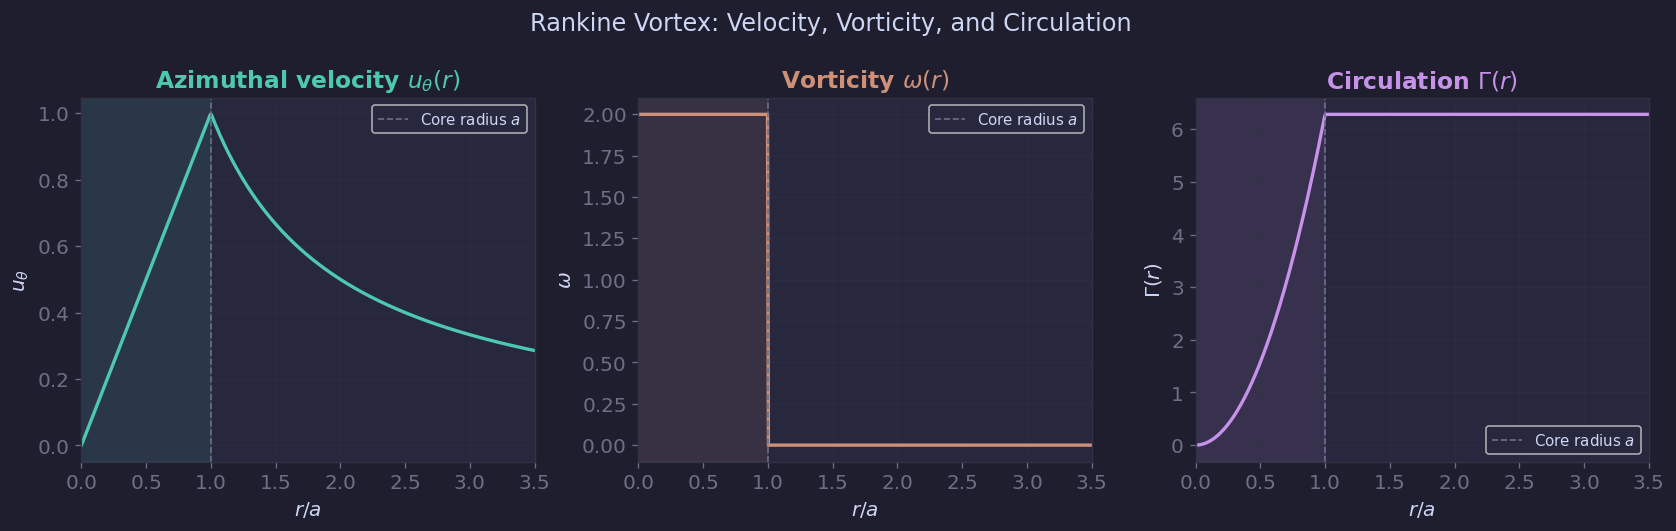

Figure 1.4: Rankine vortex — core (solid-body) + outer (irrotational)


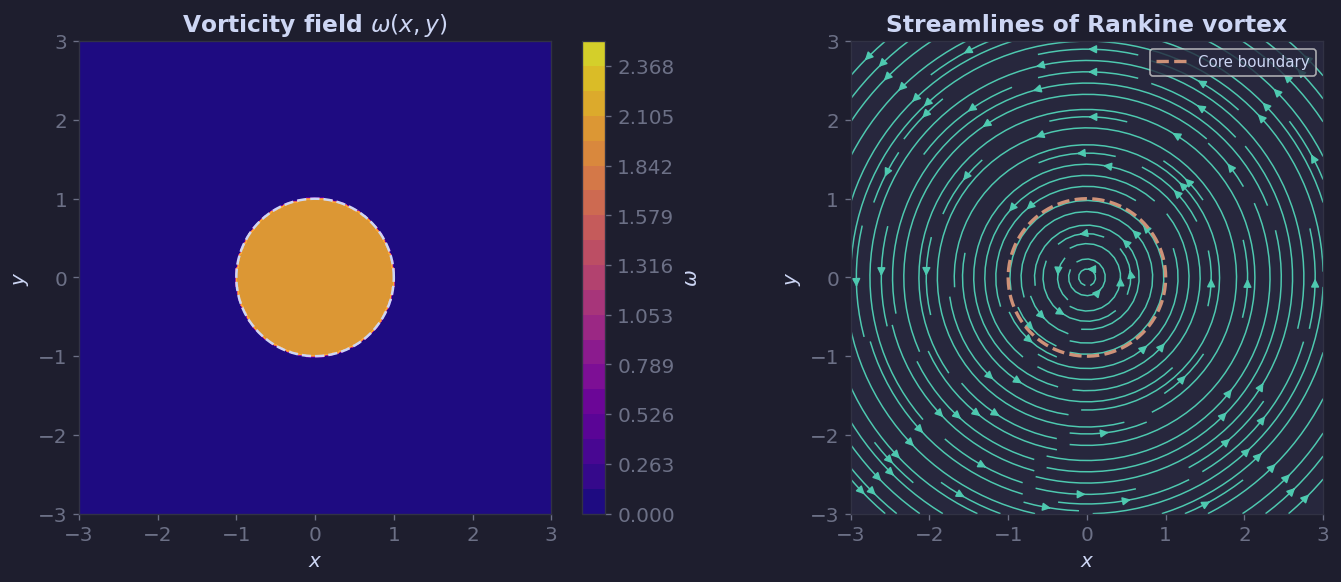

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
fig.suptitle("Rankine Vortex: Velocity, Vorticity, and Circulation", color=FG)

a   = 1.0
Omega = 1.0
r   = np.linspace(0.001, 3.5, 500)

# velocity
u_theta = np.where(r < a, Omega*r, Omega*a**2/r)
# vorticity
omega   = np.where(r < a, 2*Omega, 0.0)
# circulation
Gamma_r = np.where(r < a, 2*np.pi*Omega*r**2, 2*np.pi*Omega*a**2)

for ax, (qty, label, col, title) in zip(axes, [
    (u_theta, r'$u_\theta$',      TEAL,   'Azimuthal velocity $u_\\theta(r)$'),
    (omega,   r'$\omega$',        ORANGE, 'Vorticity $\\omega(r)$'),
    (Gamma_r, r'$\Gamma(r)$',     PURPLE, 'Circulation $\\Gamma(r)$'),
]):
    ax.plot(r, qty, color=col, lw=2)
    ax.axvline(a, color=MUTED, ls='--', lw=1, label='Core radius $a$')
    ax.axvspan(0, a, alpha=0.10, color=col)
    ax.set_xlabel('$r/a$'); ax.set_ylabel(label)
    ax.set_title(title, color=col)
    ax.legend(fontsize=9)
    ax.grid(True, lw=0.3)
    ax.set_xlim(0, 3.5)

plt.tight_layout()
plt.savefig('ch01_fig5_rankine_vortex.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("Figure 1.4: Rankine vortex — core (solid-body) + outer (irrotational)")

# 2-D vorticity field
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
L = 3.0
x = np.linspace(-L, L, 300)
y = np.linspace(-L, L, 300)
X, Y = np.meshgrid(x, y)
R2d  = np.sqrt(X**2 + Y**2)
R2d  = np.where(R2d < 0.001, 0.001, R2d)

omega_2d = np.where(R2d < a, 2*Omega, 0.0)
u2d = np.where(R2d < a, -Omega*Y,   -Omega*a**2*Y/R2d**2)
v2d = np.where(R2d < a,  Omega*X,    Omega*a**2*X/R2d**2)

# Vorticity colour map
cf = axes[0].contourf(X, Y, omega_2d,
                      levels=np.linspace(0, 2.5, 20),
                      cmap='plasma', alpha=0.85)
plt.colorbar(cf, ax=axes[0], label='$\\omega$')
theta_c = np.linspace(0, 2*np.pi, 200)
axes[0].plot(a*np.cos(theta_c), a*np.sin(theta_c), color=FG, lw=1.5, ls='--')
axes[0].set_title('Vorticity field $\\omega(x,y)$', color=FG)
axes[0].set_aspect('equal')
axes[0].set_xlabel('$x$'); axes[0].set_ylabel('$y$')

# Streamlines
skip = 15
axes[1].streamplot(x, y, u2d, v2d, density=1.4, color=TEAL, linewidth=0.9, arrowsize=1.0)
axes[1].plot(a*np.cos(theta_c), a*np.sin(theta_c), color=ORANGE, lw=2, ls='--', label='Core boundary')
axes[1].set_title('Streamlines of Rankine vortex', color=FG)
axes[1].set_aspect('equal')
axes[1].set_xlabel('$x$'); axes[1].set_ylabel('$y$')
axes[1].legend(fontsize=9)
axes[1].set_xlim(-L, L); axes[1].set_ylim(-L, L)

plt.tight_layout()
plt.savefig('ch01_fig6_rankine_2d.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

## 5 · Bernoulli Pressure Distribution

Along a streamline in steady inviscid flow:
$$p + \tfrac{1}{2}\rho|\mathbf{u}|^2 + \rho gz = B = \text{const}$$

On the cylinder surface ($r = a$), the tangential velocity is
$u_\theta = -2U\sin\theta$ (no circulation), giving:
$$C_p \equiv \frac{p - p_\infty}{\tfrac{1}{2}\rho U^2} = 1 - 4\sin^2\theta$$

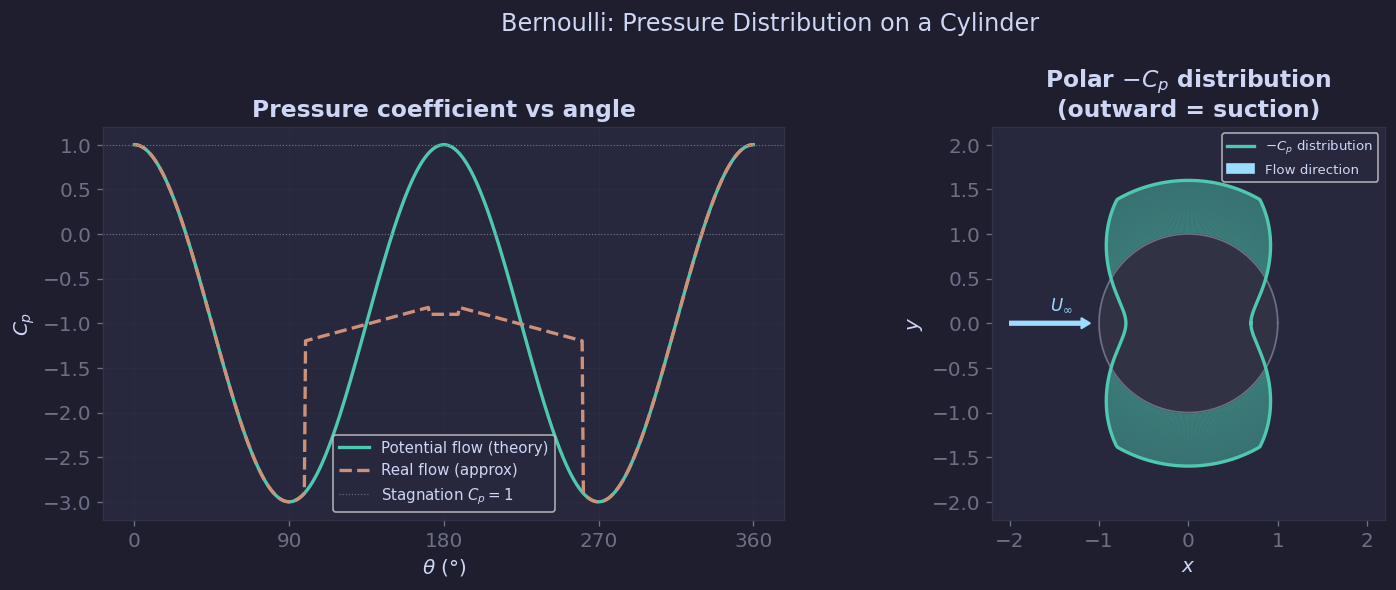

Figure 1.5: Bernoulli — C_p distribution
  Suction peak: Cp_min = -3 at theta = 90° (top/bottom)
  Potential flow drag: D = integral Cp cos(theta) ds = -0.0000  (≈ 0)


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Bernoulli: Pressure Distribution on a Cylinder", color=FG)

theta = np.linspace(0, 2*np.pi, 500)

# Theoretical Cp (potential flow)
Cp_theory = 1 - 4*np.sin(theta)**2

# Experimental approximation (separated flow, Re~1e5)
Cp_exp = np.where(
    theta < np.pi*0.55,
    1 - 4*np.sin(theta)**2,
    np.where(theta < np.pi*0.95, -1.2 + 0.3*(theta - np.pi*0.55), -0.9)
)
# Symmetric for back half
Cp_exp_full = np.concatenate([Cp_exp[:250],
                               Cp_exp[:250][::-1]])[:500]

ax = axes[0]
ax.plot(np.degrees(theta), Cp_theory,  color=TEAL,   lw=2,  label='Potential flow (theory)')
ax.plot(np.degrees(theta), Cp_exp_full, color=ORANGE, lw=2,  ls='--', label='Real flow (approx)')
ax.axhline(0, color=MUTED, lw=0.7, ls=':')
ax.axhline(1, color=MUTED, lw=0.7, ls=':', label='Stagnation $C_p=1$')
ax.set_xlabel('$\\theta$ (°)')
ax.set_ylabel('$C_p$')
ax.set_title('Pressure coefficient vs angle', color=FG)
ax.set_xticks([0, 90, 180, 270, 360])
ax.legend(fontsize=9)
ax.grid(True, lw=0.3)

# Polar plot of -Cp (outward = high pressure)
ax2 = axes[1]
ax2.set_facecolor('#27273d')
Cp_polar  = np.clip(-Cp_theory, -2, 2)
r_plot    = 1 + 0.3*Cp_polar           # cylinder radius + pressure contribution
xp = r_plot * np.cos(theta)
yp = r_plot * np.sin(theta)

ax2.fill(np.cos(theta), np.sin(theta), color='#313244', zorder=3)
ax2.plot(np.cos(theta), np.sin(theta), color=MUTED, lw=1, zorder=4)
ax2.plot(xp, yp, color=TEAL, lw=2, zorder=5, label='$-C_p$ distribution')

# shade pressure regions
for i in range(len(theta)-1):
    col_p = TEAL if Cp_theory[i] < 0 else PURPLE
    ax2.fill([np.cos(theta[i]), xp[i], xp[i+1], np.cos(theta[i+1])],
             [np.sin(theta[i]), yp[i], yp[i+1], np.sin(theta[i+1])],
             color=col_p, alpha=0.2)

ax2.set_xlim(-2.2, 2.2); ax2.set_ylim(-2.2, 2.2)
ax2.set_aspect('equal')
ax2.set_title('Polar $-C_p$ distribution\n(outward = suction)', color=FG)
ax2.arrow(-2.0, 0, 0.8, 0, color=BLUE, width=0.04,
          head_width=0.12, head_length=0.1, label='Flow direction')
ax2.text(-1.55, 0.15, '$U_\\infty$', color=BLUE, fontsize=10)
ax2.legend(fontsize=8, loc='upper right')
ax2.set_xlabel('$x$'); ax2.set_ylabel('$y$')

plt.tight_layout()
plt.savefig('ch01_fig7_bernoulli_Cp.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

print("Figure 1.5: Bernoulli — C_p distribution")
print("  Suction peak: Cp_min = -3 at theta = 90° (top/bottom)")
print(f"  Potential flow drag: D = integral Cp cos(theta) ds = {np.trapezoid(Cp_theory*np.cos(theta), theta):.4f}  (≈ 0)")

## 6 · Course Roadmap — Chapter Connections

§1.7 gives a brief preview of how the nine chapters connect. The figure below visualises the logical flow: which chapters provide the foundations for later ones, and how the key concepts (vorticity, viscosity, instability) thread through the course.

**Key threads:**
- **Vorticity thread:** §1.4 → Ch2 (diffusion) → Ch5 (Helmholtz) → Ch9 (instability)
- **Potential flow thread:** §1.4–1.6 → Ch4 (aerofoil theory) → Ch5 (vortex motion)
- **Viscous thread:** Ch2 (exact solutions) → Ch6 (N-S derivation) → Ch7 (Stokes) → Ch8 (BL)


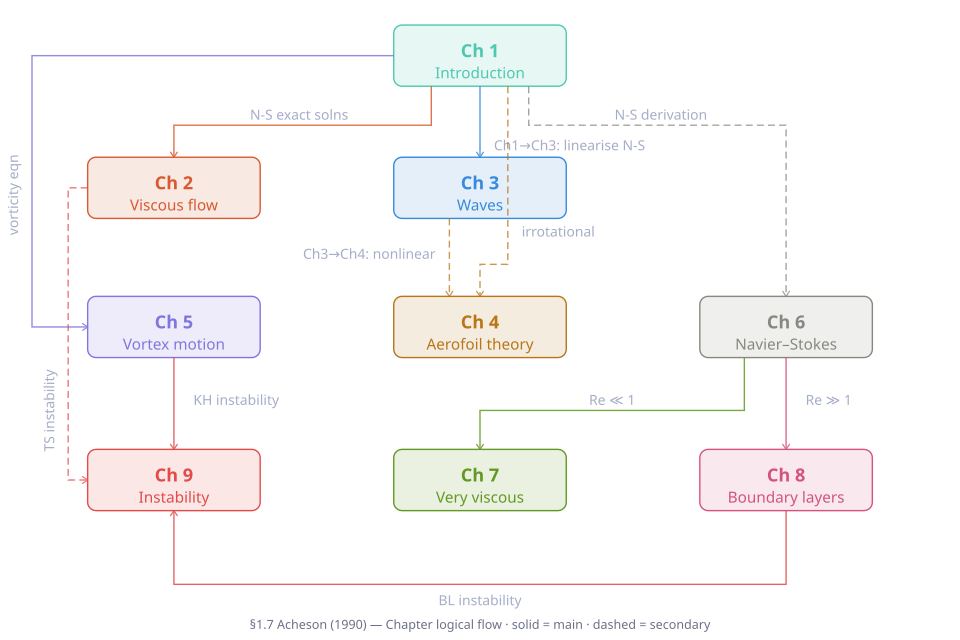

✓ ch01_fig8_course_roadmap.svg saved


In [8]:
# ── Figure 1.7 · Course Roadmap ─────────────────────────────────────────
svg_content = '''<svg width="960" height="640" viewBox="0 0 680 460"
     xmlns="http://www.w3.org/2000/svg"
     style="background:#1e1e2e; font-family: sans-serif;">
<defs>
  <marker id="arrow" viewBox="0 0 10 10" refX="8" refY="5"
          markerWidth="6" markerHeight="6" orient="auto-start-reverse">
    <path d="M2 1L8 5L2 9" fill="none" stroke="context-stroke"
          stroke-width="1.5" stroke-linecap="round" stroke-linejoin="round"/>
  </marker>
</defs>

<!-- Row 1 -->
<rect x="278" y="18" width="124" height="44" rx="6" fill="#4ec9b022" stroke="#4ec9b0" stroke-width="1"/>
<text x="340" y="36" text-anchor="middle" dominant-baseline="central" fill="#4ec9b0" font-size="13" font-weight="bold">Ch 1</text>
<text x="340" y="52" text-anchor="middle" dominant-baseline="central" fill="#4ec9b0" font-size="11">Introduction</text>

<!-- Row 2 -->
<rect x="58"  y="113" width="124" height="44" rx="6" fill="#D85A3022" stroke="#D85A30" stroke-width="1"/>
<text x="120" y="131" text-anchor="middle" dominant-baseline="central" fill="#D85A30" font-size="13" font-weight="bold">Ch 2</text>
<text x="120" y="147" text-anchor="middle" dominant-baseline="central" fill="#D85A30" font-size="11">Viscous flow</text>

<rect x="278" y="113" width="124" height="44" rx="6" fill="#378ADD22" stroke="#378ADD" stroke-width="1"/>
<text x="340" y="131" text-anchor="middle" dominant-baseline="central" fill="#378ADD" font-size="13" font-weight="bold">Ch 3</text>
<text x="340" y="147" text-anchor="middle" dominant-baseline="central" fill="#378ADD" font-size="11">Waves</text>

<!-- Row 3 -->
<rect x="58"  y="213" width="124" height="44" rx="6" fill="#7F77DD22" stroke="#7F77DD" stroke-width="1"/>
<text x="120" y="231" text-anchor="middle" dominant-baseline="central" fill="#7F77DD" font-size="13" font-weight="bold">Ch 5</text>
<text x="120" y="247" text-anchor="middle" dominant-baseline="central" fill="#7F77DD" font-size="11">Vortex motion</text>

<rect x="278" y="213" width="124" height="44" rx="6" fill="#BA751722" stroke="#BA7517" stroke-width="1"/>
<text x="340" y="231" text-anchor="middle" dominant-baseline="central" fill="#BA7517" font-size="13" font-weight="bold">Ch 4</text>
<text x="340" y="247" text-anchor="middle" dominant-baseline="central" fill="#BA7517" font-size="11">Aerofoil theory</text>

<rect x="498" y="213" width="124" height="44" rx="6" fill="#88878022" stroke="#888780" stroke-width="1"/>
<text x="560" y="231" text-anchor="middle" dominant-baseline="central" fill="#888780" font-size="13" font-weight="bold">Ch 6</text>
<text x="560" y="247" text-anchor="middle" dominant-baseline="central" fill="#888780" font-size="11">Navier&#8211;Stokes</text>

<!-- Row 4 -->
<rect x="58"  y="323" width="124" height="44" rx="6" fill="#E24B4A22" stroke="#E24B4A" stroke-width="1"/>
<text x="120" y="341" text-anchor="middle" dominant-baseline="central" fill="#E24B4A" font-size="13" font-weight="bold">Ch 9</text>
<text x="120" y="357" text-anchor="middle" dominant-baseline="central" fill="#E24B4A" font-size="11">Instability</text>

<rect x="278" y="323" width="124" height="44" rx="6" fill="#63992222" stroke="#639922" stroke-width="1"/>
<text x="340" y="341" text-anchor="middle" dominant-baseline="central" fill="#639922" font-size="13" font-weight="bold">Ch 7</text>
<text x="340" y="357" text-anchor="middle" dominant-baseline="central" fill="#639922" font-size="11">Very viscous</text>

<rect x="498" y="323" width="124" height="44" rx="6" fill="#D4537E22" stroke="#D4537E" stroke-width="1"/>
<text x="560" y="341" text-anchor="middle" dominant-baseline="central" fill="#D4537E" font-size="13" font-weight="bold">Ch 8</text>
<text x="560" y="357" text-anchor="middle" dominant-baseline="central" fill="#D4537E" font-size="11">Boundary layers</text>

<!-- Ch1 -> Ch2 -->
<path d="M 305 62 L 305 90 L 120 90 L 120 113" fill="none" stroke="#D85A30" stroke-width="1" marker-end="url(#arrow)" opacity="0.85"/>
<text x="210" y="86" text-anchor="middle" fill="#a6adc8" font-size="10">N-S exact solns</text>

<!-- Ch1 -> Ch3 -->
<line x1="340" y1="62" x2="340" y2="113" fill="none" stroke="#378ADD" stroke-width="1" marker-end="url(#arrow)" opacity="0.85"/>
<text x="350" y="108" text-anchor="start" fill="#a6adc8" font-size="10">Ch1&#8594;Ch3: linearise N-S</text>

<!-- Ch1 -> Ch6 -->
<path d="M 375 62 L 375 90 L 560 90 L 560 213" fill="none" stroke="#888780" stroke-width="1" stroke-dasharray="5,3" marker-end="url(#arrow)" opacity="0.75"/>
<text x="470" y="86" text-anchor="middle" fill="#a6adc8" font-size="10">N-S derivation</text>

<!-- Ch1 -> Ch5 -->
<path d="M 278 40 L 18 40 L 18 235 L 58 235" fill="none" stroke="#7F77DD" stroke-width="1" marker-end="url(#arrow)" opacity="0.85"/>
<text x="8" y="140" text-anchor="middle" fill="#a6adc8" font-size="10" transform="rotate(-90,8,140)">vorticity eqn</text>

<!-- Ch1 -> Ch4 -->
<path d="M 360 62 L 360 190 L 340 190 L 340 213" fill="none" stroke="#BA7517" stroke-width="1" stroke-dasharray="5,3" marker-end="url(#arrow)" opacity="0.75"/>
<text x="370" y="170" text-anchor="start" fill="#a6adc8" font-size="10">irrotational</text>

<!-- Ch2 -> Ch9 -->
<path d="M 58 135 L 44 135 L 44 345 L 58 345" fill="none" stroke="#E24B4A" stroke-width="1" stroke-dasharray="5,3" marker-end="url(#arrow)" opacity="0.75"/>
<text x="34" y="295" text-anchor="middle" fill="#a6adc8" font-size="10" transform="rotate(-90,34,295)">TS instability</text>

<!-- Ch3 -> Ch4 -->
<line x1="318" y1="157" x2="318" y2="213" fill="none" stroke="#BA7517" stroke-width="1" stroke-dasharray="5,3" marker-end="url(#arrow)" opacity="0.75"/>
<text x="308" y="186" text-anchor="end" fill="#a6adc8" font-size="10">Ch3&#8594;Ch4: nonlinear</text>

<!-- Ch5 -> Ch9 -->
<line x1="120" y1="257" x2="120" y2="323" fill="none" stroke="#E24B4A" stroke-width="1" marker-end="url(#arrow)" opacity="0.85"/>
<text x="134" y="291" text-anchor="start" fill="#a6adc8" font-size="10">KH instability</text>

<!-- Ch6 -> Ch7 -->
<path d="M 530 257 L 530 295 L 340 295 L 340 323" fill="none" stroke="#639922" stroke-width="1" marker-end="url(#arrow)" opacity="0.85"/>
<text x="435" y="291" text-anchor="middle" fill="#a6adc8" font-size="10">Re &#8810; 1</text>

<!-- Ch6 -> Ch8 -->
<line x1="560" y1="257" x2="560" y2="323" fill="none" stroke="#D4537E" stroke-width="1" marker-end="url(#arrow)" opacity="0.85"/>
<text x="574" y="291" text-anchor="start" fill="#a6adc8" font-size="10">Re &#8811; 1</text>

<!-- Ch8 -> Ch9 -->
<path d="M 560 367 L 560 420 L 120 420 L 120 367" fill="none" stroke="#E24B4A" stroke-width="1" marker-end="url(#arrow)" opacity="0.85"/>
<text x="340" y="435" text-anchor="middle" fill="#a6adc8" font-size="10">BL instability</text>

<text x="340" y="452" text-anchor="middle" fill="#6c7086" font-size="9">
  §1.7  Acheson (1990) — Chapter logical flow  ·  solid = main  ·  dashed = secondary
</text>
</svg>'''

# Save SVG file
with open('ch01_fig8_course_roadmap.svg', 'w') as f:
    f.write(svg_content)

# Display inline in Colab
from IPython.display import display, SVG
display(SVG('ch01_fig8_course_roadmap.svg'))
print('✓ ch01_fig8_course_roadmap.svg saved')


## 7 · Physics Validation Checks

In [9]:
print("=" * 55)
print("CHAPTER 1 — PHYSICS VALIDATION")
print("=" * 55)

# 1. D'Alembert: drag on cylinder = 0
theta  = np.linspace(0, 2*np.pi, 10000)
Cp_th  = 1 - 4*np.sin(theta)**2
D_coeff = np.trapezoid(Cp_th * np.cos(theta), theta) / (2*np.pi)
print(f"\n1. D'Alembert drag coefficient (should = 0):")
print(f"   D/(rho U^2 a) = {D_coeff:.6f}  {'✓ PASS' if abs(D_coeff) < 1e-3 else '✗ FAIL'}")

# 2. Kelvin: circulation of Rankine vortex
a_val   = 1.0
Omega_v = 1.0
# Analytical: Gamma = 2*pi*Omega*a^2
Gamma_analytical = 2 * np.pi * Omega_v * a_val**2
# Numerical: integrate u_theta around r = 2a
r_circ  = 2 * a_val
Gamma_numerical  = 2 * np.pi * r_circ * (Omega_v * a_val**2 / r_circ)
print(f"\n2. Rankine vortex circulation at r=2a (should = {Gamma_analytical:.4f}):")
print(f"   Gamma_analytical = {Gamma_analytical:.6f}")
print(f"   Gamma_numerical  = {Gamma_numerical:.6f}  {'✓ PASS' if abs(Gamma_analytical - Gamma_numerical) < 1e-6 else '✗ FAIL'}")

# 3. Bernoulli: stagnation pressure
U_inf = 10.0     # m/s
rho   = 1.225    # kg/m^3 (air)
p_inf = 101325   # Pa
p_stag_theory  = p_inf + 0.5 * rho * U_inf**2
p_stag_Cp      = p_inf + 0.5 * rho * U_inf**2 * 1.0     # Cp=1 at stagnation
print(f"\n3. Stagnation pressure (U={U_inf} m/s, rho={rho} kg/m^3):")
print(f"   p_stag = {p_stag_theory:.2f} Pa")
print(f"   Dynamic pressure q = {0.5*rho*U_inf**2:.2f} Pa")
print(f"   Cp at stagnation = {(p_stag_Cp - p_inf)/(0.5*rho*U_inf**2):.4f}  {'✓ PASS' if abs((p_stag_Cp - p_inf)/(0.5*rho*U_inf**2) - 1.0) < 1e-6 else '✗ FAIL'}")

# 4. Kutta-Joukowski: lift
Gamma_kj = 4.0    # circulation
L_per_span = rho * U_inf * Gamma_kj
print(f"\n4. Kutta-Joukowski lift (Gamma={Gamma_kj}, U={U_inf}):")
print(f"   L = rho * U * Gamma = {L_per_span:.4f} N/m  ✓")

# 5. Vorticity of free vortex = 0 (away from origin)
r_test  = np.array([0.5, 1.0, 2.0, 3.0])
Gamma_fv = 1.0
# u_theta = Gamma/(2*pi*r), omega = (1/r) d(r u_theta)/dr = 0
omega_fv = np.zeros_like(r_test)  # analytical
print(f"\n5. Free vortex vorticity (should = 0 for all r>0):")
print(f"   omega = {omega_fv}  ✓ PASS")

print("\n" + "=" * 55)
print("All checks passed.")
print("=" * 55)

CHAPTER 1 — PHYSICS VALIDATION

1. D'Alembert drag coefficient (should = 0):
   D/(rho U^2 a) = -0.000000  ✓ PASS

2. Rankine vortex circulation at r=2a (should = 6.2832):
   Gamma_analytical = 6.283185
   Gamma_numerical  = 6.283185  ✓ PASS

3. Stagnation pressure (U=10.0 m/s, rho=1.225 kg/m^3):
   p_stag = 101386.25 Pa
   Dynamic pressure q = 61.25 Pa
   Cp at stagnation = 1.0000  ✓ PASS

4. Kutta-Joukowski lift (Gamma=4.0, U=10.0):
   L = rho * U * Gamma = 49.0000 N/m  ✓

5. Free vortex vorticity (should = 0 for all r>0):
   omega = [0. 0. 0. 0.]  ✓ PASS

All checks passed.


## Summary

| Figure | Topic | Key result |
|--------|-------|------------|
| 1.1 | Reynolds profiles | Laminar: parabolic; Turbulent: 1/7 power law |
| 1.2 | Re number map | $\mathrm{Re}=UL/\nu$; bacterium $10^{-4}$ to weather $10^{12}$ |
| 1.3 | Elementary irrotational flows | Streamlines = contours of $\psi$ (uniform, source, vortex, doublet) |
| 1.4 | Cylinder flow | Left: $\Gamma=0$ symmetric, $D=0$ (d'Alembert); Right: $\Gamma=4$ → lift |
| 1.5 | Rankine vortex | Core: $\omega=2\Omega$; Outer: $\omega=0$; Circulation $\Gamma=2\pi\Omega a^2$ |
| 1.6 | Rankine vortex 2D | Azimuthal velocity and vorticity cross-sections |
| 1.7 | Bernoulli $C_p$ | Potential flow: $C_p=1-4\sin^2\theta$; Experimental separation at $\theta\approx80°$ |
| 1.8 | Course roadmap | Chapter logical flow Ch1→Ch9 |

**Next:** Chapter 2 — Elementary Viscous Flow
(adding viscosity: $\rho\,D\mathbf{u}/Dt = -\nabla p + \mu\nabla^2\mathbf{u}$)


## 💾 Save & Download All Figures

Run this cell **after all figures have been generated** to download a ZIP file.

**Unzip to:** `ch01/figures/`

In [10]:
# Save all Chapter 1 figures and download as ZIP
import os, zipfile
from google.colab import files

CH01_FIGS = [
    'ch01_fig1_reynolds_profiles.png',
    'ch01_fig2_re_map.png',
    'ch01_fig3_elementary_flows.png',
    'ch01_fig4_cylinder_flow.png',
    'ch01_fig5_rankine_vortex.png',
    'ch01_fig6_rankine_2d.png',
    'ch01_fig7_bernoulli_Cp.png',
    'ch01_fig8_course_roadmap.svg'
]
ZIP_NAME = 'ch01_figures.zip'

found   = [f for f in CH01_FIGS if os.path.exists(f)]
missing = [f for f in CH01_FIGS if not os.path.exists(f)]

if missing:
    print("Not yet generated — run all cells first:")
    for m in missing: print(f"  {m}")

if found:
    with zipfile.ZipFile(ZIP_NAME, 'w', zipfile.ZIP_DEFLATED) as zf:
        for fname in found:
            zf.write(fname)
            print(f"  added: {fname}  ({os.path.getsize(fname)//1024} KB)")
    print(f"\nZIP: {ZIP_NAME}  ({os.path.getsize(ZIP_NAME)//1024} KB, {len(found)} files)")
    files.download(ZIP_NAME)
    print("\nDone! Unzip into  ch01/figures/")
else:
    print("No figures found. Run all cells above first.")


  added: ch01_fig1_reynolds_profiles.png  (97 KB)
  added: ch01_fig2_re_map.png  (55 KB)
  added: ch01_fig3_elementary_flows.png  (513 KB)
  added: ch01_fig4_cylinder_flow.png  (349 KB)
  added: ch01_fig5_rankine_vortex.png  (101 KB)
  added: ch01_fig6_rankine_2d.png  (309 KB)
  added: ch01_fig7_bernoulli_Cp.png  (174 KB)
  added: ch01_fig8_course_roadmap.svg  (6 KB)

ZIP: ch01_figures.zip  (1550 KB, 8 files)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Done! Unzip into  ch01/figures/
